In [11]:
from superfv import HydroSolver, BC, ics, MUSCL_SlopeLimiter, RiemannSolver
import spd
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15
from functools import partial

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.96GB', '42.41GB']


In [3]:
def superfv_sim(p,N,P0=1,**kwargs):
    def gravity(idx, u, *, xp):
        gx = 0.0
        gy = 1.0
        out = xp.zeros_like(u)
        out[idx("mx")] = u[idx("rho")] * gx
        out[idx("my")] = u[idx("rho")] * gy
        out[idx("E")] = u[idx("mx")] * gx + u[idx("my")] * gy
        return out


    return HydroSolver(
        ic=partial(ics.rayleigh_taylor, gamma=5 / 3, P0=P0),
        gamma=5 / 3,
        rho_min=1e-10,
        P_min=1e-10,
        source=gravity,
        xlims=(0, 0.25),
        ylims=(0, 1),
        nx=N // 4,
        ny=N,
        bcy=(BC.REFLECTIVE, BC.REFLECTIVE),
        p=p,
        use_MOOD=True,
        use_NAD=True,
        use_SED=True,
        blend_troubles=False,
        MUSCL_limiter=MUSCL_SlopeLimiter.MONCEN,
        cupy=True,
    )

In [4]:
def spd_sim(p,N,P0=1,**kwargs):
    return SPD_Simulator(p=p,
                  N=(N// 4, N),
                  xlim=(0.0, 0.25),
                  ylim=(0.0, 1.0),
                  BC=(("periodic", "periodic"),  # x
                      ("reflective", "reflective"),  # y
                     ),
                  init_fct=ic.RTI(P0=1,gamma=5/3),
                  cfl_coeff=0.4,use_cupy=True,
                  time_integrator="rk3",
                  fallback="MUSCL",
                  slope_limiter="moncen",
                  scheme="SDFB",
                  potential=True,
                  NAD="",
                  PAD=True,
                  SED=True,
                  blending=False,
                  riemann_solver_fv="hllc",  # MUSCL fallback flux
                  **kwargs)
    

In [5]:
def plot_both(fv_sim, sd_sim):
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, constrained_layout=True, figsize=(5, 6))

    for ax in axs:
        ax.set_aspect("equal")
    
    x_sd = sd_sim.regular_faces()[0]
    y_sd = sd_sim.regular_faces()[1]
    z_sd = sd_sim.transpose_to_fv(sd_sim.regular_mesh(sd_sim.dm.W_cv))[0]
    
    x_fv, y_fv, _ = fv_sim.mesh.faces
    z_fv = fv_sim.snapshot_history[-1].w[0, :, :, 0].T
    
    vmin = min(z_fv.min().item(), z_sd.min().item())
    vmax = max(z_fv.max().item(), z_sd.max().item())
    
    axs[0].set_title("FV4")
    m0 = axs[0].pcolormesh(cp.asnumpy(x_fv), cp.asnumpy(y_fv), z_fv, vmin=vmin, vmax=vmax)
    
    axs[1].set_title("SD4")
    m1 = axs[1].pcolormesh(x_sd, y_sd, z_sd, vmin=vmin, vmax=vmax)
    fig.colorbar(m1, ax=axs[1], pad=0.15)
    return fig, axs

In [ ]:
NDOF=192
p=3
s1 = superfv_sim(p,NDOF,P0=1,
            NAD_rtol=1e-1)
s1.run(1.95)

In [ ]:
N = NDOF//(p+1)
s2 = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-1,
            riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

In [ ]:
plot_both(s1, s2)

In [6]:
NDOF=192
p=3
s1 = superfv_sim(p,NDOF,P0=1,
            NAD_rtol=1e-5)
s1.run(1.95)

SuperFV: 1947 steps | t=1.95e+00/1.95e+00, dt=6.71e-04 | rho_min=8.66e-01 | E_cons=1.86e+02 | wall=2.87e+01s (done)


In [9]:
N = NDOF//(p+1)
s2 = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s2.perform_time_evolution(1.95)

t=1.95, steps taken 3605, time taken 161.528, bzcps = 0.0


(<Figure size 500x600 with 3 Axes>,
 array([<Axes: title={'center': 'FV4'}>, <Axes: title={'center': 'SD4'}>],
       dtype=object))

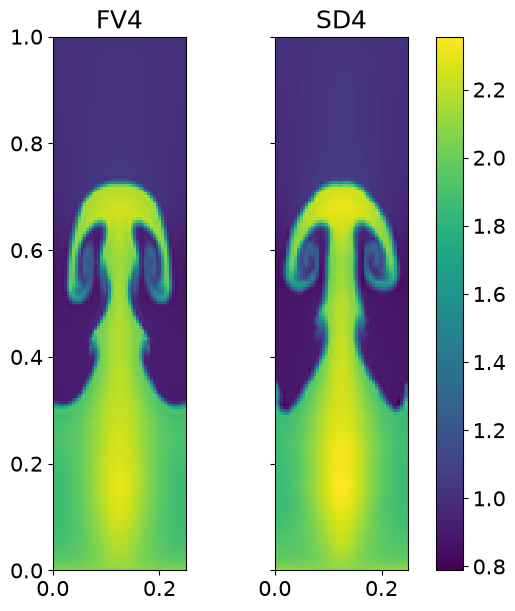

In [10]:
plot_both(s1, s2)

In [13]:
NDOF=192
p=3
s1 = superfv_sim(p,NDOF,P0=1,
            NAD_rtol=1e-5)
s1.params.hydro.riemann_solver = RiemannSolver.LLF
s1.run(1.95)

FrozenInstanceError: cannot assign to field 'riemann_solver'

In [ ]:
N = NDOF//(p+1)
s2 = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s2.perform_time_evolution(1.95)

In [ ]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-1,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

In [ ]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

In [ ]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 4],
            tolerance=1e-5,
            riemann_solver_sd="llf")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")

In [ ]:
NDOF=192
p=3
N = NDOF//(p+1)
s = spd_sim(p,N,P0=1,
            limiting_variables=[0, 1, 2, 4],
            tolerance=1e-2,
            riemann_solver_sd="hllc")
s.perform_time_evolution(1.95)
vsd.plot_field(s,s.dm.W_cv,0)
plt.gca().set_aspect("equal")